In [1]:
import geopandas as gpd

In [19]:
elevation_gdf = gpd.read_file("/mnt/warehouse/shifting_cultivation/111_result/output_file/elevation_slope_gdf_0129.gpkg")

In [20]:
import pandas as pd
import geopandas as gpd
import ast
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for selected groups: Africa, America, and Asia-Oceania
selected_continents = ["Africa", "America", "Asia-Oceania"]
elevation_gdf_s = elevation_gdf[elevation_gdf["continent"].isin(selected_continents)]

In [21]:
elevation_gdf_s.columns

Index(['orig_value', 'ref_row', 'ref_col', 'edge_flag', 'inside_mask',
       'new_elevationmerge_system:index', 'new_elevationmerge_edge_flag',
       'new_elevationmerge_elevation', 'new_elevationmerge_inside_mas',
       'new_elevationmerge_orig_value', 'new_elevationmerge_ref_col',
       'new_elevationmerge_ref_row', 'new_elevationmerge_slope',
       'new_elevationmerge_.geo', 'index_right', 'country', 'iso_code',
       'continent', 'gdlcode', 'region', 'geometry'],
      dtype='object')

In [23]:
elevation_gdf_s["new_elevationmerge_elevation"] = pd.to_numeric(
    elevation_gdf_s["new_elevationmerge_elevation"],
    errors="coerce"
)
elevation_gdf_s["new_elevationmerge_slope"] = pd.to_numeric(
    elevation_gdf_s["new_elevationmerge_slope"],
    errors="coerce"
)

In [24]:
# Group by new continent categories and compute elevation statistics
elevation_summary = elevation_gdf_s.groupby("continent")["new_elevationmerge_elevation"].describe()
print(elevation_summary)

                 count        mean         std         min         25%  \
continent                                                                
Africa        927308.0  615.920461  406.831744   -4.669291  362.117586   
America       404495.0  459.074546  583.785949  -23.952756   95.505875   
Asia-Oceania  425334.0  527.845128  487.172729 -171.444030  128.936944   

                     50%         75%          max  
continent                                          
Africa        521.048058  793.019627  4114.228682  
America       231.168627  582.947794  5075.249042  
Asia-Oceania  388.992436  812.610847  5616.229965  


In [25]:
# Group by new continent categories and compute elevation statistics
slope_summary = elevation_gdf_s.groupby("continent")["new_elevationmerge_slope"].describe()
print(slope_summary)

                 count      mean       std  min       25%       50%       75%  \
continent                                                                       
Africa        927308.0  1.370491  1.813387  0.0  0.430070  0.763343  1.467408   
America       404495.0  3.071355  4.034718  0.0  0.364649  1.017444  4.551785   
Asia-Oceania  425333.0  4.675907  4.002378  0.0  1.376767  3.787643  6.915668   

                    max  
continent                
Africa        27.371443  
America       34.667459  
Asia-Oceania  45.796538  


In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

sns.set_style("white")
plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 16,
    "axes.labelsize": 15,
    "legend.fontsize": 13
})

continent_order = ["Africa", "Asia-Oceania", "America"]

continent_colors = {
    "Africa": "#4C72B0",
    "Asia-Oceania": "#DD8452",
    "America": "#55A868"
}

In [27]:
def plot_elevation_by_continent(df, continent, out_dir):
    fig, ax = plt.subplots(figsize=(5, 4))

    data = df[df["continent"] == continent]["new_elevationmerge_elevation"]

    sns.histplot(
        data,
        bins=50,
        stat="percent",
        element="step",
        linewidth=2,
        color=continent_colors[continent],
        ax=ax
    )

    # Percentiles
    q25, q50, q75, q95= np.percentile(data, [25, 50, 75, 95])
    for q in [q25, q50, q75, q95]:
        ax.axvline(q, color="black", linestyle="dashed", linewidth=1)

    ax.set_xlabel("Elevation (m)")
    ax.set_ylabel("Share of area (%)")
    ax.set_title(f"Elevation distribution", loc="left", fontweight="bold")

    plt.tight_layout()
    plt.savefig(
        f"{out_dir}/elevation_{continent.replace(' ', '_')}.png",
        dpi=600,
        bbox_inches="tight"
    )
    plt.close()


In [28]:
def plot_slope_by_continent(df, continent, out_dir):
    fig, ax = plt.subplots(figsize=(5, 4))

    df["new_elevationmerge_slope"].apply(type).value_counts()

    data = (
        df.loc[df["continent"] == continent, "new_elevationmerge_slope"]
          .dropna()
          .values
    )


    bins = np.linspace(0, 40, 40)
    hist, edges = np.histogram(data, bins=bins)
    hist = hist / hist.sum() * 100

    ax.step(
        edges[:-1],
        hist,
        where="post",
        color=continent_colors[continent],
        linewidth=2
    )

    # Percentiles
    q25, q50, q75, q95= np.percentile(data, [25, 50, 75, 95])
    for q in [q25, q50, q75, q95]:
        ax.axvline(q, color="black", linestyle="dashed", linewidth=1)

    ax.set_xlim(0, 40)
    ax.set_xlabel("Slope (degrees)")
    ax.set_ylabel("Share of area (%)")
    ax.set_title(f"Slope distribution", loc="left", fontweight="bold")

    plt.tight_layout()
    plt.savefig(
        f"{out_dir}/slope_{continent.replace(' ', '_')}.png",
        dpi=600,
        bbox_inches="tight"
    )
    plt.close()


In [30]:
import os
output_dir = "/mnt/warehouse/shifting_cultivation/111_result/figure/continent_panels/test_test"

os.makedirs(output_dir, exist_ok=True) 

for cont in continent_order:
    plot_elevation_by_continent(elevation_gdf_s, cont, output_dir)
    plot_slope_by_continent(elevation_gdf_s, cont, output_dir)

In [31]:
import pandas as pd
biome_continent_area = pd.read_csv('/mnt/warehouse/shifting_cultivation/111_result/output_file/weighted_biomes_continent_noEU.csv')

In [32]:
biome_continent_area

,Unnamed: 0,continent,biome_group,weighted_count,area_mha,percentage
0,0,Africa,Dry Broadleaf Forests,6583.00,0.658300,0.702039
1,1,Africa,Moist Broadleaf Forests,388843.75,38.884375,41.467953
2,2,Africa,Others,23864.75,2.386475,2.545039
3,3,Africa,Savanna & Woodland,518405.50,51.840550,55.284969
4,4,America,Coniferous Forests,17344.25,1.734425,4.246561
5,5,America,Dry Broadleaf Forests,27241.00,2.724100,6.669678
6,6,America,Moist Broadleaf Forests,314996.25,31.499625,77.123587
7,7,America,Others,17242.50,1.724250,4.221648
8,8,America,Savanna & Woodland,31606.50,3.160650,7.738526
9,9,Asia-Oceania,Coniferous Forests,2575.50,0.257550,0.603655


In [15]:
elevation_gdf_s[elevation_gdf_s["continent"] == "Asia-Oceania"]["new_elevationmerge_slope"].isna().sum()

0

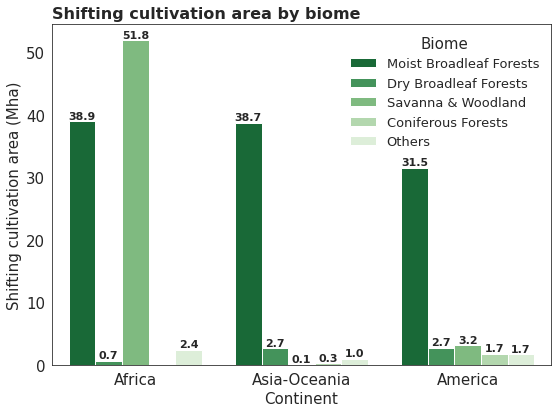

In [33]:
fig, ax = plt.subplots(figsize=(8, 6))

continent_order = [
    "Africa",
    "Asia-Oceania",
    "America"
]

biome_order = [
    "Moist Broadleaf Forests",
    "Dry Broadleaf Forests",
    "Savanna & Woodland",
    "Coniferous Forests",
    'Others'
]

sns.barplot(
    data=biome_continent_area,
    x="continent",
    y="area_mha",
    hue="biome_group",
    hue_order=biome_order,
    order=continent_order,
    palette=sns.color_palette("Greens_r", 5),
    errorbar=None,
    ax=ax
)

for p in ax.patches:
    h = p.get_height()
    if h >= 0:
        ax.text(
            p.get_x() + p.get_width() / 2,
            h + 0.4,
            f"{h:.1f}",
            ha="center",
            fontsize=11,
            fontweight="bold"
        )


ax.set_xlabel("Continent")
ax.set_ylabel("Shifting cultivation area (Mha)")
ax.set_title("Shifting cultivation area by biome", loc="left", fontweight="bold")


ax.legend(title="Biome", frameon=False)

plt.tight_layout()
# plt.savefig(
#     "/mnt/warehouse/shifting_cultivation/111_result/figure/continent_panels/t1/biome_continent_panel2.png",
#     dpi=600,
#     bbox_inches="tight"
# )
plt.show()
plt.close()
